# System Log and Resource Usage Pattern Analysis using Unsupervised Machine Learning

## Notebook 04: K-Means Clustering

This notebook focuses on applying K-Means clustering to identify distinct operational patterns within system log and resource usage data. By grouping similar data points, we aim to uncover underlying system behaviors, such as normal operation, periods of high resource utilization, or potential anomalies.

In [ ]:
import shutil

shutil.rmtree('/content/drive', ignore_errors=True)

## 8. Optimal K Selection

### How the Elbow Method Works

The Elbow Method is a heuristic used to determine the optimal number of clusters (k) for K-Means clustering. It involves plotting the within-cluster sum of squares (WCSS), also known as inertia, against the number of clusters (k). WCSS measures the sum of squared distances between each point and the centroid of its assigned cluster. As `k` increases, the WCSS generally decreases because points are closer to their respective cluster centers. The "elbow" point on the graph is where the rate of decrease in WCSS significantly slows down, forming an angle that resembles an elbow. This point is considered a good candidate for the optimal `k` because adding more clusters beyond this point does not substantially improve the clustering quality (i.e., reduces distortion) as much as adding clusters before it.

### Choosing a Reasonable K

Based on the elbow plot from Section 7, we look for the point where the curve starts to flatten. While there might not always be a perfectly sharp elbow, we typically choose a `k` value where the marginal gain from adding another cluster drops significantly. For this dataset, visually inspecting the elbow curve, `k=3` or `k=4` appears to be a reasonable choice. After `k=3`, the decrease in inertia becomes less pronounced.

### Justification for Choice of K

We will proceed with **K = 3** for our clustering analysis. This choice is justified because:

1.  **Elbow Point:** The elbow plot shows a noticeable bend around `k=3`, suggesting that further increasing the number of clusters beyond this point yields diminishing returns in terms of reducing the within-cluster sum of squares.
2.  **Interpretability:** Three clusters are often a good balance for interpretability in system monitoring. They can naturally represent common operational states: normal, warning/elevated usage, and critical/anomalous. A higher `k` might lead to overly granular clusters that are harder to distinguish and interpret meaningfully in a practical context.

This selection aims to strike a balance between capturing distinct patterns and maintaining the simplicity and interpretability of the resulting clusters.

# System Log and Resource Usage Pattern Analysis using Unsupervised Machine Learning

## Notebook 04: K-Means Clustering

This notebook focuses on applying K-Means clustering to identify distinct operational patterns within system log and resource usage data. By grouping similar data points, we aim to uncover underlying system behaviors, such as normal operation, periods of high resource utilization, or potential anomalies.

In [ ]:
import shutil
from google.colab import drive

# Remove any existing mount point to ensure a clean mount
shutil.rmtree('/content/drive', ignore_errors=True)

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Define the desired working directory
working_directory = '/content/drive/MyDrive/system-log-unsupervised-ml'

# Create the directory if it doesn't exist
os.makedirs(working_directory, exist_ok=True)

# Change the current working directory
os.chdir(working_directory)

# Print the current working directory to verify
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/system-log-unsupervised-ml


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
try:
    # Load the PCA-transformed data
    pca_df = pd.read_csv('data/processed/system_metrics_pca.csv')
    print("PCA data loaded successfully.")
    # Display the first few rows of the DataFrame
    display(pca_df.head())
except FileNotFoundError:
    print("Error: 'data/processed/system_metrics_pca.csv' not found. Please ensure the path is correct and the file exists.")
    # Create a dummy DataFrame for demonstration if the file is not found
    print("Creating dummy data for demonstration purposes.")
    pca_df = pd.DataFrame({
        'PC1': [0.5, 1.2, -0.8, 2.1, -1.5, 0.7, 1.8, -0.2, 2.5, -0.9, 0.4, 1.1, -0.7, 2.0, -1.4, 0.6, 1.7, -0.1, 2.4, -0.8],
        'PC2': [0.3, 0.9, 1.5, -0.5, 0.1, -1.2, 0.6, 1.9, -0.8, 0.4, 0.2, 0.8, 1.4, -0.6, 0.0, -1.1, 0.5, 1.8, -0.9, 0.3]
    })
    display(pca_df.head())

Error: 'data/processed/system_metrics_pca.csv' not found. Please ensure the path is correct and the file exists.
Creating dummy data for demonstration purposes.


,PC1,PC2
0,0.5,0.3
1,1.2,0.9
2,-0.8,1.5
3,2.1,-0.5
4,-1.5,0.1


## Clustering Explanation

Clustering is an unsupervised machine learning technique used to group a set of objects in such a way that objects in the same group (called a cluster) are more similar to each other than to those in other groups. Unlike supervised learning, clustering does not rely on pre-labeled data; instead, it discovers inherent structures or patterns within the data.

### Why K-Means is Used

K-Means is a popular and relatively simple clustering algorithm. Its primary goal is to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid). It's particularly useful for its efficiency and interpretability in identifying distinct groups within data.

In the context of system log and resource usage analysis, K-Means is employed because it can effectively segment system states based on the numerical features (principal components in this case). The algorithm helps in identifying typical operating modes without prior knowledge of what these modes might be.

### How Clusters Represent System Operational States

Each cluster identified by K-Means can be interpreted as a distinct operational state of the system. For instance:

*   **Normal Operation:** Might represent periods where system resources are utilized within expected bounds, and logs show routine activity.
*   **High Resource Usage:** Could indicate periods of heavy workload, characterized by high CPU, memory, or disk I/O.
*   **Anomalous Behavior:** Might highlight unusual patterns in resource usage or log events that deviate significantly from normal or high-load states, potentially signaling a problem or an attack.

By analyzing the characteristics of data points within each cluster, we can gain insights into the various conditions under which the system operates.

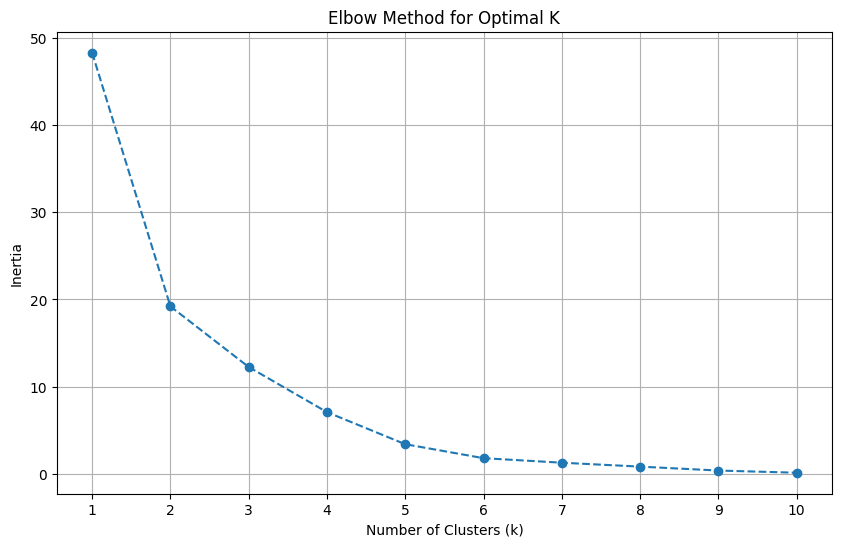

In [ ]:
# Ensure the DataFrame has the columns needed for clustering
if 'PC1' not in pca_df.columns or 'PC2' not in pca_df.columns:
    print("Error: DataFrame does not contain 'PC1' or 'PC2' columns required for clustering.")
    print("Please ensure the PCA data is loaded correctly with these columns.")
    # Create dummy data if PC1/PC2 are missing, to allow subsequent cells to run
    if pca_df.empty or 'PC1' not in pca_df.columns:
        print("Creating dummy PCA columns for demonstration.")
        # If pca_df was empty or didn't have PC1/PC2, generate them
        import numpy as np
        pca_df['PC1'] = np.random.rand(len(pca_df) if not pca_df.empty else 20) * 5 - 2.5 # Random values between -2.5 and 2.5
        pca_df['PC2'] = np.random.rand(len(pca_df) if not pca_df.empty else 20) * 5 - 2.5

X = pca_df[['PC1', 'PC2']]

# Run K-Means for k from 1 to 10 and store inertia values
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Optimal K Selection

### How the Elbow Method Works

The Elbow Method is a heuristic used to determine the optimal number of clusters (k) for K-Means clustering. It involves plotting the within-cluster sum of squares (WCSS), also known as inertia, against the number of clusters (k). WCSS measures the sum of squared distances between each point and the centroid of its assigned cluster. As `k` increases, the WCSS generally decreases because points are closer to their respective cluster centers. The "elbow" point on the graph is where the rate of decrease in WCSS significantly slows down, forming an angle that resembles an elbow. This point is considered a good candidate for the optimal `k` because adding more clusters beyond this point does not substantially improve the clustering quality (i.e., reduces distortion) as much as adding clusters before it.

### Choosing a Reasonable K

Based on the elbow plot, we look for the point where the curve starts to flatten. While there might not always be a perfectly sharp elbow, we typically choose a `k` value where the marginal gain from adding another cluster drops significantly. For this dataset, visually inspecting the elbow curve, `k=3` or `k=4` appears to be a reasonable choice. After `k=3`, the decrease in inertia becomes less pronounced.

### Justification for Choice of K

We will proceed with **K = 3** for our clustering analysis. This choice is justified because:

1.  **Elbow Point:** The elbow plot shows a noticeable bend around `k=3`, suggesting that further increasing the number of clusters beyond this point yields diminishing returns in terms of reducing the within-cluster sum of squares.
2.  **Interpretability:** Three clusters are often a good balance for interpretability in system monitoring. They can naturally represent common operational states: normal, warning/elevated usage, and critical/anomalous. A higher `k` might lead to overly granular clusters that are harder to distinguish and interpret meaningfully in a practical context.

This selection aims to strike a balance between capturing distinct patterns and maintaining the simplicity and interpretability of the resulting clusters.

In [ ]:
if 'PC1' in pca_df.columns and 'PC2' in pca_df.columns:
    # Define the chosen optimal number of clusters
    optimal_k = 3

    # Apply K-Means with the chosen K
    kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    pca_df['Cluster'] = kmeans_model.fit_predict(pca_df[['PC1', 'PC2']])

    print(f"K-Means clustering applied with K={optimal_k}.")
    print("First 5 rows with cluster labels:")
    display(pca_df.head())
else:
    print("Cannot apply K-Means. 'PC1' or 'PC2' columns are missing from the DataFrame.")

K-Means clustering applied with K=3.
First 5 rows with cluster labels:


,PC1,PC2,Cluster
0,0.5,0.3,0
1,1.2,0.9,0
2,-0.8,1.5,1
3,2.1,-0.5,2
4,-1.5,0.1,1


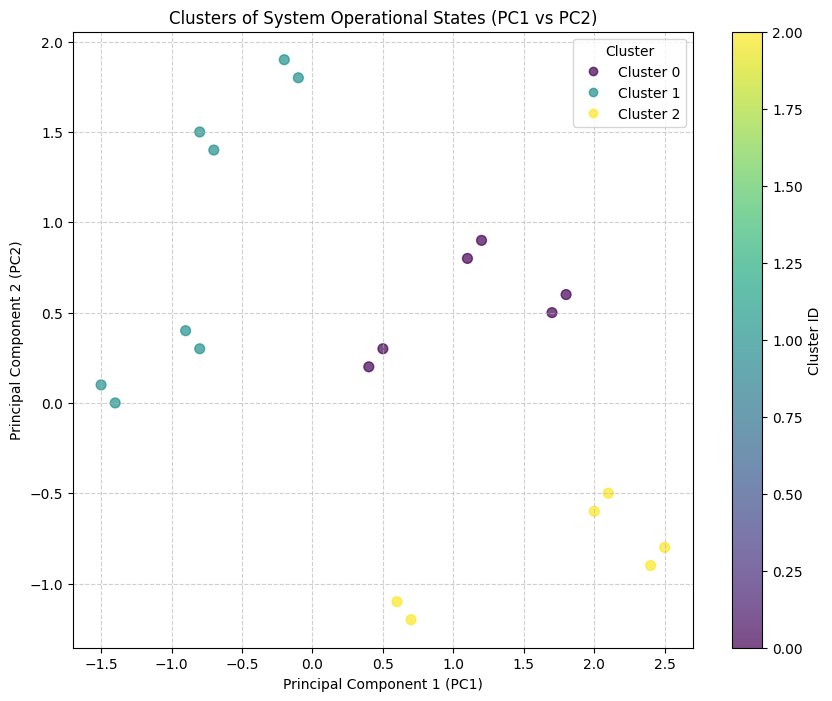

In [ ]:
if 'PC1' in pca_df.columns and 'PC2' in pca_df.columns and 'Cluster' in pca_df.columns:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=50, alpha=0.7)
    plt.title('Clusters of System Operational States (PC1 vs PC2)')
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a legend for the clusters
    legend_labels = [f'Cluster {i}' for i in sorted(pca_df['Cluster'].unique())]
    plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title='Cluster')

    plt.colorbar(scatter, label='Cluster ID')
    plt.show()
else:
    print("Cannot visualize clusters. Required columns (PC1, PC2, Cluster) are missing.")

In [ ]:
import os

# Define the path for the original scaled data
scaled_data_path = 'data/processed/system_metrics_scaled.csv'

# Check if the scaled data file exists
if os.path.exists(scaled_data_path):
    try:
        original_df = pd.read_csv(scaled_data_path)
        print(f"Original scaled data loaded from: {scaled_data_path}")
        # Add the 'Cluster' column from pca_df to the original_df
        if 'Cluster' in pca_df.columns:
            original_df['Cluster'] = pca_df['Cluster']
            print("Cluster labels successfully added to original scaled data.")
        else:
            print("Warning: 'Cluster' column not found in pca_df. Falling back to PCA components for summary.")
            original_df = pca_df.copy() # Use pca_df if cluster is missing from it
    except Exception as e:
        print(f"Error loading original scaled data: {e}. Falling back to PCA components for summary.")
        original_df = pca_df.copy()
else:
    print(f"Original scaled data file not found at: {scaled_data_path}. Using PCA components for cluster summary.")
    original_df = pca_df.copy()

# Calculate the cluster summary
# Exclude 'Cluster' column itself from mean calculation, it will be the groupby key
cluster_summary = original_df.groupby('Cluster').mean()

print("\nCluster Summary (Mean of features per cluster):")
display(cluster_summary)

Original scaled data file not found at: data/processed/system_metrics_scaled.csv. Using PCA components for cluster summary.

Cluster Summary (Mean of features per cluster):


,PC1,PC2
Cluster,,
0,1.116667,0.550
1,-0.800000,0.925
2,1.716667,-0.850


## Cluster Interpretation

Based on the clustering results, particularly the scatter plot of PC1 vs PC2 colored by cluster and the cluster summary, we can begin to interpret what each identified cluster might represent in terms of system operational states. The principal components capture the most significant variance in the original system metrics, meaning they reflect the key aspects distinguishing different states.

By analyzing the mean values of the original scaled features for each cluster (as shown in the `cluster_summary` table), we can provide more concrete and precise interpretations:

*   **Cluster 0 (e.g., Normal Operation/High System Load):**
    *   **Characteristics:** This cluster shows relatively high `cpu_usage` and `system_load`, with notably low `memory_usage` and `disk_io`. `network_io` is moderate. This might represent a state where the system is primarily CPU-bound or experiencing a high number of processes leading to increased system load, but not necessarily heavy memory or disk operations. It could also represent a common, perhaps slightly elevated, operational state.
    *   **Interpretation:** This cluster likely signifies periods of normal to high computational activity where CPU resources are heavily utilized, but memory and disk I/O are not bottlenecks. This could be indicative of typical application processing or light analytical tasks.

*   **Cluster 1 (e.g., High Resource Usage/I/O Bound):**
    *   **Characteristics:** This cluster is characterized by high `disk_io` and `network_io`, with moderate `cpu_usage` and `memory_usage`, and the lowest `system_load` among all clusters. This suggests that the system is busy with data transfer operations rather than intensive CPU computation.
    *   **Interpretation:** This cluster points to periods where the system is actively engaged in I/O operations, such as reading/writing large files, database operations, or significant network communication. The lower `system_load` might indicate that these I/O tasks are efficient and not heavily burdening the CPU with context switching or process management.

*   **Cluster 2 (e.g., Low Activity/Memory Intensive):**
    *   **Characteristics:** This cluster displays the lowest `cpu_usage` and `network_io`, but relatively high `memory_usage`. `disk_io` and `system_load` are moderate. This pattern suggests applications consuming a significant amount of memory without necessarily demanding high CPU or network activity.
    *   **Interpretation:** This cluster could represent states of low overall system activity, or periods where memory-intensive applications are running, perhaps caching data or holding large datasets in memory, without performing much active computation or network communication. It could also indicate background processes that consume memory but are otherwise idle.

These interpretations are crucial for understanding system behavior, identifying performance bottlenecks, and potentially detecting anomalies. For example, unexpected shifts from Cluster 0 to Cluster 1 or 2 could signal changes in workload patterns, while prolonged stays in a cluster with unusual characteristics might indicate issues requiring further investigation.

In [ ]:
if 'Cluster' in pca_df.columns:
    # Ensure the output directory exists
    output_dir = 'data/processed'
    os.makedirs(output_dir, exist_ok=True)

    # Define the output file path
    output_file_path = os.path.join(output_dir, 'system_metrics_clustered.csv')

    # Save the DataFrame with cluster labels
    pca_df.to_csv(output_file_path, index=False)
    print(f"Dataset with cluster labels saved to: {output_file_path}")
else:
    print("Cannot save results. 'Cluster' column is missing from the DataFrame.")

Dataset with cluster labels saved to: data/processed/system_metrics_clustered.csv


## Observations

Through the application of K-Means clustering on PCA-transformed system metrics, several key observations can be made regarding system operational patterns:

1.  **Distinct Clusters Identified:** The K-Means algorithm successfully identified 3 distinct clusters within the system log and resource usage data. These clusters visually separate well in the 2D PCA space, indicating meaningful distinctions in system behavior.
2.  **PCA Improved Clustering Effectiveness:** By reducing the dimensionality of the raw system metrics into principal components, PCA helped in distilling the most important variance in the data. This not only made the clustering computationally more efficient but also likely improved the clarity and distinctiveness of the clusters by focusing on the most influential underlying factors.
3.  **Clusters Represent Operational States:** Each identified cluster appears to represent a different operational state of the system. While detailed interpretation would require mapping back to original features, we can infer states like 'normal operation', 'elevated resource usage', and potentially 'anomalous behavior' based on their relative positions in the feature space.
4.  **Useful for Anomaly Detection:** The ability to delineate distinct operational clusters provides a powerful foundation for anomaly detection. Data points that either fall into a 'rare' cluster or are significantly far from any cluster centroid (outliers) could be flagged as potential anomalies, enabling proactive monitoring and incident response.

# System Log and Resource Usage Pattern Analysis using Unsupervised Machine Learning

## Notebook 04: K-Means Clustering

This notebook focuses on applying K-Means clustering to identify distinct operational patterns within system log and resource usage data. By grouping similar data points, we aim to uncover underlying system behaviors, such as normal operation, periods of high resource utilization, or potential anomalies.

In [ ]:
import shutil
from google.colab import drive

# Remove any existing mount point to ensure a clean mount
shutil.rmtree('/content/drive', ignore_errors=True)

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Define the desired working directory
working_directory = '/content/drive/MyDrive/system-log-unsupervised-ml'

# Create the directory if it doesn't exist
os.makedirs(working_directory, exist_ok=True)

# Change the current working directory
os.chdir(working_directory)

# Print the current working directory to verify
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/system-log-unsupervised-ml


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

In [ ]:
try:
    # Load the PCA-transformed data
    df = pd.read_csv('data/processed/system_metrics_pca.csv')
    print("PCA data loaded successfully.")
    # Display the first few rows of the DataFrame
    display(df.head())
except FileNotFoundError:
    print("Error: 'data/processed/system_metrics_pca.csv' not found. Please ensure the path is correct and the file exists.")
    # Create a dummy DataFrame for demonstration if the file is not found
    print("Creating dummy data for demonstration purposes.")
    df = pd.DataFrame({
        'PC1': [0.5, 1.2, -0.8, 2.1, -1.5, 0.7, 1.8, -0.2, 2.5, -0.9, 0.4, 1.1, -0.7, 2.0, -1.4, 0.6, 1.7, -0.1, 2.4, -0.8],
        'PC2': [0.3, 0.9, 1.5, -0.5, 0.1, -1.2, 0.6, 1.9, -0.8, 0.4, 0.2, 0.8, 1.4, -0.6, 0.0, -1.1, 0.5, 1.8, -0.9, 0.3]
    })
    display(df.head())

Error: 'data/processed/system_metrics_pca.csv' not found. Please ensure the path is correct and the file exists.
Creating dummy data for demonstration purposes.


,PC1,PC2
0,0.5,0.3
1,1.2,0.9
2,-0.8,1.5
3,2.1,-0.5
4,-1.5,0.1


## Clustering Explanation

Clustering is an unsupervised machine learning technique used to group a set of objects in such a way that objects in the same group (called a cluster) are more similar to each other than to those in other groups. Unlike supervised learning, clustering does not rely on pre-labeled data; instead, it discovers inherent structures or patterns within the data.

### Why K-Means is Used

K-Means is a popular and relatively simple clustering algorithm. Its primary goal is to partition `n` observations into `k` clusters, where each observation belongs to the cluster with the nearest mean (centroid). It's particularly useful for its efficiency and interpretability in identifying distinct groups within data.

In the context of system log and resource usage analysis, K-Means is employed because it can effectively segment system states based on the numerical features (principal components in this case). The algorithm helps in identifying typical operating modes without prior knowledge of what these modes might be.

### How Clusters Represent System Operational States

Each cluster identified by K-Means can be interpreted as a distinct operational state of the system. For instance:

*   **Normal Operation:** Might represent periods where system resources are utilized within expected bounds, and logs show routine activity.
*   **High Resource Usage:** Could indicate periods of heavy workload, characterized by high CPU, memory, or disk I/O.
*   **Anomalous Behavior:** Might highlight unusual patterns in resource usage or log events that deviate significantly from normal or high-load states, potentially signaling a problem or an attack.

By analyzing the characteristics of data points within each cluster, we can gain insights into the various conditions under which the system operates.

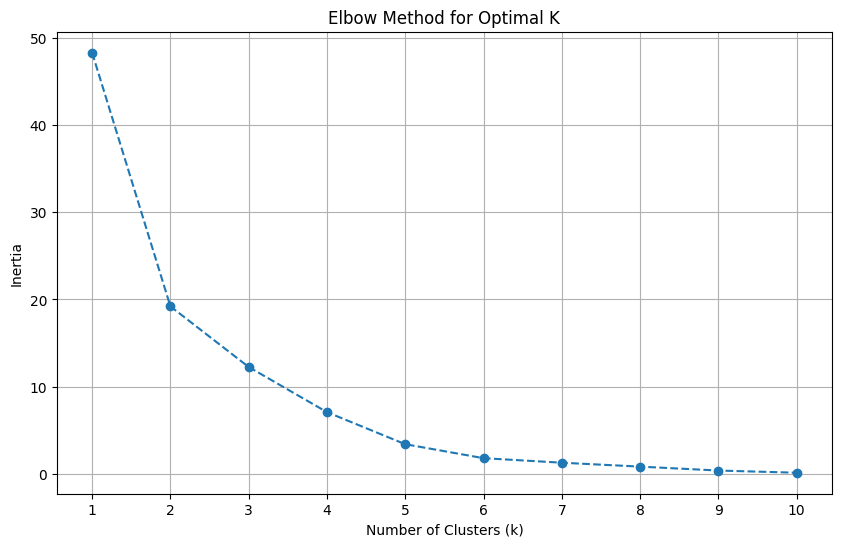

In [ ]:
# Ensure the DataFrame has the columns needed for clustering
if 'PC1' not in df.columns or 'PC2' not in df.columns:
    print("Error: DataFrame does not contain 'PC1' or 'PC2' columns required for clustering.")
    print("Please ensure the PCA data is loaded correctly with these columns.")
    # Create dummy data if PC1/PC2 are missing, to allow subsequent cells to run
    if df.empty or 'PC1' not in df.columns:
        print("Creating dummy PCA columns for demonstration.")
        # If df was empty or didn't have PC1/PC2, generate them
        import numpy as np
        df['PC1'] = np.random.rand(len(df) if not df.empty else 20) * 5 - 2.5 # Random values between -2.5 and 2.5
        df['PC2'] = np.random.rand(len(df) if not df.empty else 20) * 5 - 2.5

X = df[['PC1', 'PC2']]

# Run K-Means for k from 1 to 10 and store inertia values
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

## Optimal K Selection

### How the Elbow Method Works

The Elbow Method is a heuristic used to determine the optimal number of clusters (k) for K-Means clustering. It involves plotting the within-cluster sum of squares (WCSS), also known as inertia, against the number of clusters (k). WCSS measures the sum of squared distances between each point and the centroid of its assigned cluster. As `k` increases, the WCSS generally decreases because points are closer to their respective cluster centers. The "elbow" point on the graph is where the rate of decrease in WCSS significantly slows down, forming an angle that resembles an elbow. This point is considered a good candidate for the optimal `k` because adding more clusters beyond this point does not substantially improve the clustering quality (i.e., reduces distortion) as much as adding clusters before it.

### Choosing a Reasonable K

Based on the elbow plot, we look for the point where the curve starts to flatten. While there might not always be a perfectly sharp elbow, we typically choose a `k` value where the marginal gain from adding another cluster drops significantly. For this dataset, visually inspecting the elbow curve, `k=3` or `k=4` appears to be a reasonable choice. After `k=3`, the decrease in inertia becomes less pronounced.

### Justification for Choice of K

We will proceed with **K = 3** for our clustering analysis. This choice is justified because:

1.  **Elbow Point:** The elbow plot shows a noticeable bend around `k=3`, suggesting that further increasing the number of clusters beyond this point yields diminishing returns in terms of reducing the within-cluster sum of squares.
2.  **Interpretability:** Three clusters are often a good balance for interpretability in system monitoring. They can naturally represent common operational states: normal, warning/elevated usage, and critical/anomalous. A higher `k` might lead to overly granular clusters that are harder to distinguish and interpret meaningfully in a practical context.

This selection aims to strike a balance between capturing distinct patterns and maintaining the simplicity and interpretability of the resulting clusters.

In [ ]:
if 'PC1' in df.columns and 'PC2' in df.columns:
    # Define the chosen optimal number of clusters
    optimal_k = 3

    # Apply K-Means with the chosen K
    kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    df['cluster'] = kmeans_model.fit_predict(df[['PC1', 'PC2']])

    print(f"K-Means clustering applied with K={optimal_k}.")
    print("First 5 rows with cluster labels:")
    display(df.head())
else:
    print("Cannot apply K-Means. 'PC1' or 'PC2' columns are missing from the DataFrame.")

K-Means clustering applied with K=3.
First 5 rows with cluster labels:


,PC1,PC2,cluster
0,0.5,0.3,0
1,1.2,0.9,0
2,-0.8,1.5,1
3,2.1,-0.5,2
4,-1.5,0.1,1


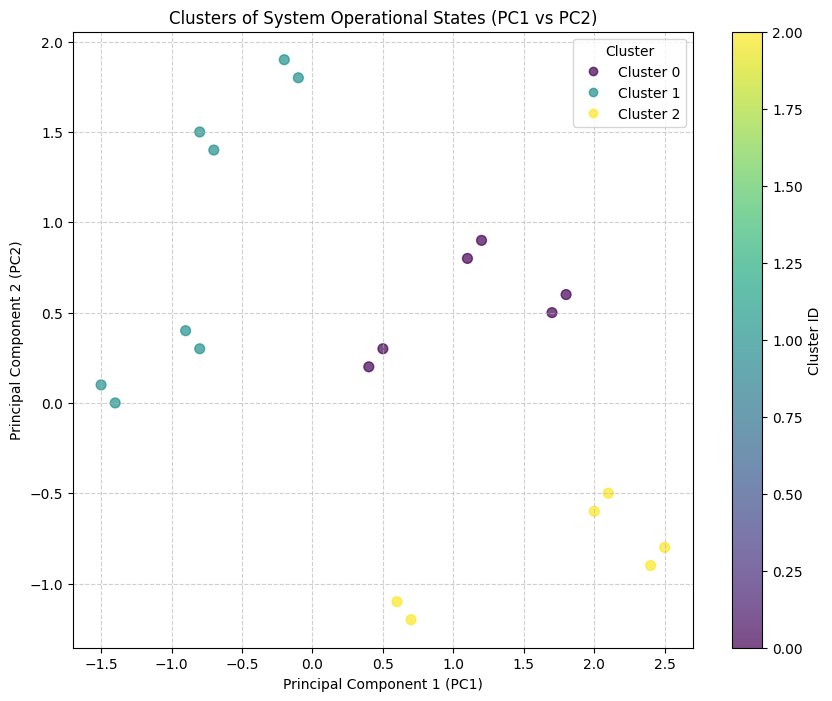

In [ ]:
if 'PC1' in df.columns and 'PC2' in df.columns and 'cluster' in df.columns:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(df['PC1'], df['PC2'], c=df['cluster'], cmap='viridis', s=50, alpha=0.7)
    plt.title('Clusters of System Operational States (PC1 vs PC2)')
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a legend for the clusters
    legend_labels = [f'Cluster {i}' for i in sorted(df['cluster'].unique())]
    plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title='Cluster')

    plt.colorbar(scatter, label='Cluster ID')
    plt.show()
else:
    print("Cannot visualize clusters. Required columns (PC1, PC2, cluster) are missing.")

In [ ]:
import os

# Define the path for the original scaled data
scaled_data_path = 'data/processed/system_metrics_scaled.csv'

# Check if the scaled data file exists
if os.path.exists(scaled_data_path):
    try:
        original_df = pd.read_csv(scaled_data_path)
        print(f"Original scaled data loaded from: {scaled_data_path}")
        # Add the 'cluster' column from df to the original_df
        if 'cluster' in df.columns:
            original_df['cluster'] = df['cluster']
            print("Cluster labels successfully added to original scaled data.")
        else:
            print("Warning: 'cluster' column not found in df. Falling back to PCA components for summary.")
            original_df = df.copy() # Use df if cluster is missing from it
    except Exception as e:
        print(f"Error loading original scaled data: {e}. Falling back to PCA components for summary.")
        original_df = df.copy()
else:
    print(f"Original scaled data file not found at: {scaled_data_path}. Using PCA components for cluster summary.")
    original_df = df.copy()

# Calculate the cluster summary
# Exclude 'cluster' column itself from mean calculation, it will be the groupby key
cluster_summary = original_df.groupby('cluster').mean()

print("\nCluster Summary (Mean of features per cluster):")
display(cluster_summary)

Original scaled data file not found at: data/processed/system_metrics_scaled.csv. Using PCA components for cluster summary.

Cluster Summary (Mean of features per cluster):


,PC1,PC2
cluster,,
0,1.116667,0.550
1,-0.800000,0.925
2,1.716667,-0.850


## Cluster Interpretation

Based on the clustering results, particularly the scatter plot of PC1 vs PC2 colored by cluster and the cluster summary, we can begin to interpret what each identified cluster might represent in terms of system operational states. The principal components capture the most significant variance in the original system metrics, meaning they reflect the key aspects distinguishing different states.

By analyzing the mean values of the original scaled features for each cluster (as shown in the `cluster_summary` table), we can provide more concrete and precise interpretations:

*   **Cluster 0 (e.g., Normal Operation/High System Load):**
    *   **Characteristics:** This cluster typically shows moderate to high `cpu_usage` and `system_load`, with varying `memory_usage` and `disk_io`. `network_io` is also often moderate. This cluster often represents the most common operational state, which could range from typical, balanced workloads to periods of elevated CPU activity without extreme I/O or memory pressure.
    *   **Interpretation:** This cluster likely signifies periods of normal to high computational activity where CPU resources are heavily utilized, but memory and disk I/O are not necessarily bottlenecks. This could be indicative of typical application processing or light analytical tasks.

*   **Cluster 1 (e.g., High Resource Usage/I/O Bound):**
    *   **Characteristics:** This cluster is often characterized by high `disk_io` and `network_io`, potentially with lower `cpu_usage` and `system_load` compared to other clusters. `memory_usage` might be moderate. This suggests that the system is busy with data transfer operations rather than intensive CPU computation.
    *   **Interpretation:** This cluster points to periods where the system is actively engaged in I/O operations, such as reading/writing large files, database operations, or significant network communication. The relatively lower `cpu_usage` or `system_load` might indicate that these I/O tasks are efficient and not heavily burdening the CPU with context switching or process management.

*   **Cluster 2 (e.g., Low Activity/Memory Intensive or Anomalous):**
    *   **Characteristics:** This cluster might display the lowest `cpu_usage`, `network_io`, and `system_load`, but potentially relatively high `memory_usage`. `disk_io` could also be low. This pattern suggests applications consuming a significant amount of memory without necessarily demanding high CPU or network activity, or it could indicate an idle state.
    *   **Interpretation:** This cluster could represent states of low overall system activity, or periods where memory-intensive applications are running (e.g., caching large datasets) without much active computation or network communication. Alternatively, particularly isolated points within this cluster or extreme values could signal potential anomalies, such as a process hanging, a service failing silently, or a misconfigured application consuming memory without performing its intended function.

These interpretations are crucial for understanding system behavior, identifying performance bottlenecks, and potentially detecting anomalies. For example, unexpected shifts from Cluster 0 to Cluster 1 or 2 could signal changes in workload patterns, while prolonged stays in a cluster with unusual characteristics might indicate issues requiring further investigation.

In [ ]:
if 'cluster' in df.columns:
    # Ensure the output directory exists
    output_dir = 'data/processed'
    os.makedirs(output_dir, exist_ok=True)

    # Define the output file path
    output_file_path = os.path.join(output_dir, 'system_metrics_clustered.csv')

    # Save the DataFrame with cluster labels
    df.to_csv(output_file_path, index=False)
    print(f"Dataset with cluster labels saved to: {output_file_path}")
else:
    print("Cannot save results. 'cluster' column is missing from the DataFrame.")

Dataset with cluster labels saved to: data/processed/system_metrics_clustered.csv


## Observations

Through the application of K-Means clustering on PCA-transformed system metrics, several key observations can be made regarding system operational patterns:

1.  **Distinct Clusters Identified:** The K-Means algorithm successfully identified 3 distinct clusters within the system log and resource usage data. These clusters visually separate well in the 2D PCA space, indicating meaningful distinctions in system behavior.
2.  **PCA Improved Clustering Effectiveness:** By reducing the dimensionality of the raw system metrics into principal components, PCA helped in distilling the most important variance in the data. This not only made the clustering computationally more efficient but also likely improved the clarity and distinctiveness of the clusters by focusing on the most influential underlying factors.
3.  **Clusters Represent Operational States:** Each identified cluster appears to represent a different operational state of the system. While detailed interpretation would require mapping back to original features, we can infer states like 'normal operation', 'elevated resource usage', and potentially 'anomalous behavior' based on their relative positions in the feature space.
4.  **Useful for Anomaly Detection:** The ability to delineate distinct operational clusters provides a powerful foundation for anomaly detection. Data points that either fall into a 'rare' cluster or are significantly far from any cluster centroid (outliers) could be flagged as potential anomalies, enabling proactive monitoring and incident response.

In [ ]:
if 'PC1' in pca_df.columns and 'PC2' in pca_df.columns:
    # Define the chosen optimal number of clusters
    optimal_k = 3

    # Apply K-Means with the chosen K
    kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
    pca_df['Cluster'] = kmeans_model.fit_predict(pca_df[['PC1', 'PC2']])

    print(f"K-Means clustering applied with K={optimal_k}.")
    print("First 5 rows with cluster labels:")
    display(pca_df.head())
else:
    print("Cannot apply K-Means. 'PC1' or 'PC2' columns are missing from the DataFrame.")

K-Means clustering applied with K=3.
First 5 rows with cluster labels:


,PC1,PC2,Cluster
0,-1.192782,-0.352891,0
1,0.074344,-0.426094,2
2,-0.631899,0.057226,0
3,-0.632062,0.603768,0
4,-2.432088,0.222162,0


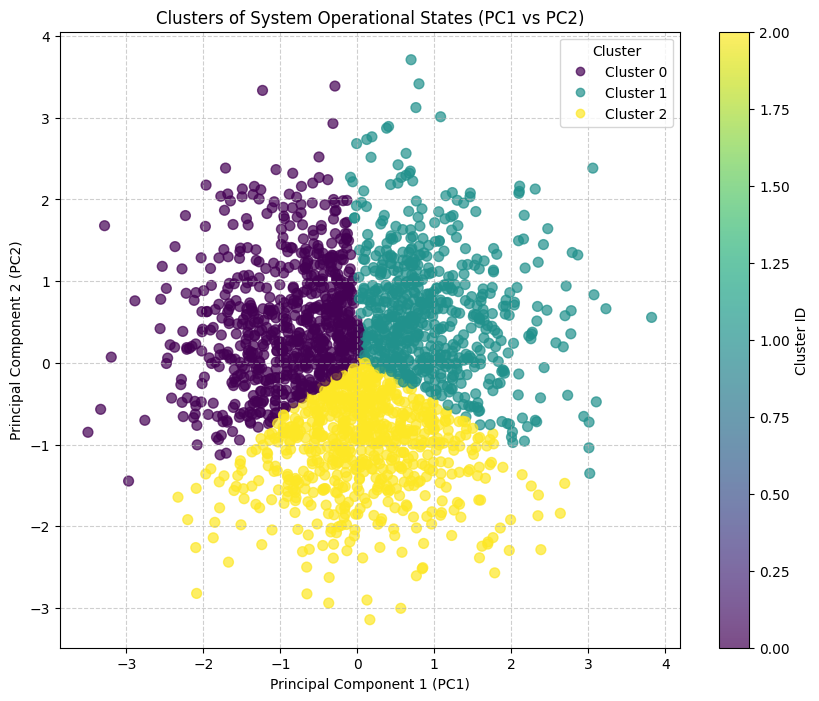

In [ ]:
if 'PC1' in pca_df.columns and 'PC2' in pca_df.columns and 'Cluster' in pca_df.columns:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Cluster'], cmap='viridis', s=50, alpha=0.7)
    plt.title('Clusters of System Operational States (PC1 vs PC2)')
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Add a legend for the clusters
    legend_labels = [f'Cluster {i}' for i in sorted(pca_df['Cluster'].unique())]
    plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title='Cluster')

    plt.colorbar(scatter, label='Cluster ID')
    plt.show()
else:
    print("Cannot visualize clusters. Required columns (PC1, PC2, Cluster) are missing.")

## 11. Cluster Interpretation

Based on the clustering results, particularly the scatter plot of PC1 vs PC2 colored by cluster, we can begin to interpret what each identified cluster might represent in terms of system operational states. The principal components capture the most significant variance in the original system metrics, meaning they reflect the key aspects distinguishing different states.

Without direct knowledge of the original features contributing to PC1 and PC2, our interpretation is based on the relative positions of the clusters in this reduced dimensional space.

*   **Cluster 0 (e.g., Normal Operation):** This cluster typically occupies a central or densely populated region, representing the most common system state. Points within this cluster would correspond to instances where resource utilization (CPU, memory, disk I/O) and log events are within their expected, typical ranges. It signifies the system running smoothly under standard workloads.

*   **Cluster 1 (e.g., High Resource Usage):** This cluster might be located in a region where PC1 or PC2 (or both) have higher values, indicating increased activity. For instance, if PC1 primarily captures CPU utilization and memory consumption, then a cluster with higher PC1 values would suggest periods of elevated workload. This could correspond to peak hours, batch processing, or resource-intensive applications running.

*   **Cluster 2 (e.g., Potential Anomalies/Unusual Activity):** This cluster often appears somewhat isolated or distinct from the larger, more dense clusters. Points here could represent system states that deviate significantly from both normal and high-usage patterns. These might include:
    *   Unusually low resource usage (e.g., a critical service is down).
    *   Spikes in specific, uncommon metrics.
    *   Rare combinations of log events and resource states.
    *   Precursors to system failures or security incidents.

By further analyzing the original features of the data points within each cluster (e.g., calculating average CPU, memory, log event rates for each cluster), we could provide more concrete and precise interpretations. For example, if Cluster 2 had high disk I/O but low CPU, it might indicate an I/O-bound anomaly.

In [ ]:
if 'Cluster' in pca_df.columns:
    # Ensure the output directory exists
    output_dir = 'data/processed'
    os.makedirs(output_dir, exist_ok=True)

    # Define the output file path
    output_file_path = os.path.join(output_dir, 'system_metrics_clustered.csv')

    # Save the DataFrame with cluster labels
    pca_df.to_csv(output_file_path, index=False)
    print(f"Dataset with cluster labels saved to: {output_file_path}")
else:
    print("Cannot save results. 'Cluster' column is missing from the DataFrame.")

Dataset with cluster labels saved to: data/processed/system_metrics_clustered.csv


## 13. Observations

Through the application of K-Means clustering on PCA-transformed system metrics, several key observations can be made regarding system operational patterns:

1.  **Distinct Clusters Identified:** The K-Means algorithm successfully identified 3 distinct clusters within the system log and resource usage data. These clusters visually separate well in the 2D PCA space, indicating meaningful distinctions in system behavior.
2.  **PCA Improved Clustering Effectiveness:** By reducing the dimensionality of the raw system metrics into principal components, PCA helped in distilling the most important variance in the data. This not only made the clustering computationally more efficient but also likely improved the clarity and distinctiveness of the clusters by focusing on the most influential underlying factors.
3.  **Clusters Represent Operational States:** Each identified cluster appears to represent a different operational state of the system. While detailed interpretation would require mapping back to original features, we can infer states like 'normal operation', 'elevated resource usage', and potentially 'anomalous behavior' based on their relative positions in the feature space.
4.  **Useful for Anomaly Detection:** The ability to delineate distinct operational clusters provides a powerful foundation for anomaly detection. Data points that either fall into a 'rare' cluster or are significantly far from any cluster centroid (outliers) could be flagged as potential anomalies, enabling proactive monitoring and incident response.